In [2]:
pip install geopy


   ---------------------------------------- 0/2 [geographiclib]
   ---------------------------------------- 0/2 [geographiclib]
   ---------------------------------------- 0/2 [geographiclib]
   ---------------------------------------- 0/2 [geographiclib]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   ---------------------------------------- 2/2 [geopy]

Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install pmdarima

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spyder 4.1.5 requires pyqt5<5.13; python_version >= "3", which is not installed.
spyder 4.1.5 requires pyqtwebengine<5.13; python_version >= "3", which is not installed.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   -------------------------------------- 615.5/615.5 kB 684.7 kB/s eta 0:00:00
   ---------------------------------------- 14.9/14.9 MB 2.5 MB/s eta 0:00:00
   ---------------------------------------- 10.0/10.0 MB 2.4 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 20.4
    Uninstalling packaging-20.4:
      Successfully uninstalled packaging-20.4
  Attempting uninstall: numpy
    Found existing installation: numpy 1.19.2
    Uninstalling numpy-1.19.2:
      Successfully uninstalled numpy-1.19.2
  Attempting uninstall: patsy
    Found existing installation: patsy 0.5.1
    Uninstalling patsy-0.5.1:
      Successfully uninstalled patsy-0.5.1
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.12.0
    Uninstalling statsmodels-0.12.0:
      Successfully uninstalled statsmodels-0.12.0


In [2]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic
from geopy.geocoders import Nominatim
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import seaborn as sns
import matplotlib.pyplot as plt
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from matplotlib import rcParams

In [2]:
df = pd.read_csv("weatherAUS.csv", parse_dates=['Date'])

In [5]:
df['Location'].unique()

array(['Albury', 'BadgerysCreek', 'Cobar', 'CoffsHarbour', 'Moree',
       'Newcastle', 'NorahHead', 'NorfolkIsland', 'Penrith', 'Richmond',
       'Sydney', 'SydneyAirport', 'WaggaWagga', 'Williamtown',
       'Wollongong', 'Canberra', 'Tuggeranong', 'MountGinini', 'Ballarat',
       'Bendigo', 'Sale', 'MelbourneAirport', 'Melbourne', 'Mildura',
       'Nhil', 'Portland', 'Watsonia', 'Dartmoor', 'Brisbane', 'Cairns',
       'GoldCoast', 'Townsville', 'Adelaide', 'MountGambier', 'Nuriootpa',
       'Woomera', 'Albany', 'Witchcliffe', 'PearceRAAF', 'PerthAirport',
       'Perth', 'SalmonGums', 'Walpole', 'Hobart', 'Launceston',
       'AliceSprings', 'Darwin', 'Katherine', 'Uluru'], dtype=object)

In [4]:
df['Location'] = df['Location'].copy()

In [3]:
correctname_dict = {'BadgerysCreek':'Badgerys Creek', 'CoffsHarbour':'Coffs Harbour', 'NorahHead': 'Norah Head', 'NorfolkIsland': 'Norfolk Island', 'SydneyAirport': 'Sydney Airport', 'WaggaWagga': 'Wagga Wagga', 'MountGinini': 'Mount Ginini', 'MelbourneAirport': 'Melbourne Airport','MountGambier': 'Mount Gambier', 'PearceRAAF': 'Pearce RAAF', 'PerthAirport': 'Perth Airport', 'SalmonGums': 'Salmon Gums', 'AliceSprings': 'Alice Springs'}

In [5]:
df['Location'] = df['Location'].replace(correctname_dict)

In [11]:
df['Location'].unique()

array(['Albury', 'Badgerys Creek', 'Cobar', 'Coffs Harbour', 'Moree',
       'Newcastle', 'Norah Head', 'Norfolk Island', 'Penrith', 'Richmond',
       'Sydney', 'Sydney Airport', 'Wagga Wagga', 'Williamtown',
       'Wollongong', 'Canberra', 'Tuggeranong', 'Mount Ginini',
       'Ballarat', 'Bendigo', 'Sale', 'Melbourne Airport', 'Melbourne',
       'Mildura', 'Nhil', 'Portland', 'Watsonia', 'Dartmoor', 'Brisbane',
       'Cairns', 'GoldCoast', 'Townsville', 'Adelaide', 'Mount Gambier',
       'Nuriootpa', 'Woomera', 'Albany', 'Witchcliffe', 'Pearce RAAF',
       'Perth Airport', 'Perth', 'Salmon Gums', 'Walpole', 'Hobart',
       'Launceston', 'Alice Springs', 'Darwin', 'Katherine', 'Uluru'],
      dtype=object)

In [6]:
cities = pd.unique(df['Location'])

In [8]:
# get city coordinates
geolocator = Nominatim(user_agent="my_app")

notFound = []
city_coordinates = {}
for city in cities:
    location = geolocator.geocode(city)
    if location is not None:
        city_coordinates[city] = (location.latitude, location.longitude)
    else: 
        notFound.append(city)
print(city_coordinates)

{'Albury': (-36.0737734, 146.9135265), 'Badgerys Creek': (-33.8831452, 150.742466), 'Cobar': (-31.9666628, 145.3045054), 'Coffs Harbour': (-30.2985996, 153.1094116), 'Moree': (-29.4617202, 149.8407153), 'Newcastle': (54.9738474, -1.6131572), 'Norah Head': (-33.2816667, 151.5677778), 'Norfolk Island': (-29.0328038, 167.9483137), 'Penrith': (54.6639133, -2.7522047), 'Richmond': (37.5385087, -77.43428), 'Sydney': (-33.8698439, 151.2082848), 'Sydney Airport': (-33.9498935, 151.1819682), 'Wagga Wagga': (-35.115, 147.3677778), 'Williamtown': (-32.815, 151.8427778), 'Wollongong': (-34.4243941, 150.89385), 'Canberra': (-35.2975906, 149.1012676), 'Tuggeranong': (-35.4209771, 149.0921341), 'Mount Ginini': (-35.5297437, 148.7725396), 'Ballarat': (-37.5623013, 143.8605645), 'Bendigo': (-36.7590183, 144.2826718), 'Sale': (44.980656, 8.809348), 'Melbourne Airport': (-37.6667554, 144.8288501), 'Melbourne': (-37.8142454, 144.9631732), 'Mildura': (-34.195274, 142.1503146), 'Nhil': (53.5539592, 10.00970

In [9]:
len(city_coordinates.keys())

49

In [10]:
print(notFound)

[]


In [11]:
# Pre-calculate city distances
city_distances = {}

for location in cities:
    current_location = city_coordinates[location]
    distances = {}
    for city, coordinates in city_coordinates.items():
        if city != location:
            distances[city] = geodesic(current_location, coordinates).km
        if distances:
            nearest_city = min(distances, key=distances.get)
            city_distances[location] = nearest_city


In [12]:
print(city_distances)

{'Albury': 'Wagga Wagga', 'Badgerys Creek': 'Sydney Airport', 'Cobar': 'Mildura', 'Coffs Harbour': 'Williamtown', 'Moree': 'Coffs Harbour', 'Newcastle': 'Penrith', 'Norah Head': 'Williamtown', 'Norfolk Island': 'Coffs Harbour', 'Penrith': 'Newcastle', 'Richmond': 'Walpole', 'Sydney': 'Sydney Airport', 'Sydney Airport': 'Sydney', 'Wagga Wagga': 'Albury', 'Williamtown': 'Norah Head', 'Wollongong': 'Sydney Airport', 'Canberra': 'Tuggeranong', 'Tuggeranong': 'Canberra', 'Mount Ginini': 'Tuggeranong', 'Ballarat': 'Melbourne Airport', 'Bendigo': 'Ballarat', 'Sale': 'GoldCoast', 'Melbourne Airport': 'Melbourne', 'Melbourne': 'Watsonia', 'Mildura': 'Nuriootpa', 'Nhil': 'GoldCoast', 'Portland': 'Richmond', 'Watsonia': 'Melbourne', 'Dartmoor': 'Penrith', 'Brisbane': 'Coffs Harbour', 'Cairns': 'Townsville', 'GoldCoast': 'Nhil', 'Townsville': 'Cairns', 'Adelaide': 'Nuriootpa', 'Mount Gambier': 'Ballarat', 'Nuriootpa': 'Adelaide', 'Woomera': 'Nuriootpa', 'Albany': 'Sale', 'Witchcliffe': 'Perth', 'P

In [25]:
df.dtypes

Date             datetime64[ns]
Location                 object
MinTemp                 float64
MaxTemp                 float64
Rainfall                float64
Evaporation             float64
Sunshine                float64
WindGustDir              object
WindGustSpeed           float64
WindDir9am               object
WindDir3pm               object
WindSpeed9am            float64
WindSpeed3pm            float64
Humidity9am             float64
Humidity3pm             float64
Pressure9am             float64
Pressure3pm             float64
Cloud9am                float64
Cloud3pm                float64
Temp9am                 float64
Temp3pm                 float64
RainToday                object
RainTomorrow             object
dtype: object

In [13]:
df.isnull().sum().sum()

np.int64(343248)

In [14]:
df['Rainfall'].isnull().sum()

np.int64(3261)

In [15]:
df = df.sort_values(['Location', 'Date'])

# 2. Function to apply asfreq within date range of each location
def fill_missing_dates_and_track(group):
    group = group.set_index('Date').sort_index()

    # Define the actual date range per location
    full_index = pd.date_range(start=group.index.min(), end=group.index.max(), freq='D')

    # Reindex with full date range to get missing dates
    reindexed = group.reindex(full_index)

    # Track missing dates
    num_missing = reindexed.isnull().all(axis=1).sum()  # only count rows where all columns are NaN (i.e. added by reindex)
    percent_missing = (num_missing / len(reindexed)) * 100

    reindexed['Location'] = group['Location'].iloc[0]  # restore location column
    return reindexed, num_missing, percent_missing

# 3. Apply to each location and collect results
filled_data = []
missing_summary = []

for location, group in df.groupby("Location"):
    reindexed, num_missing, percent_missing = fill_missing_dates_and_track(group)
    filled_data.append(reindexed)
    missing_summary.append({
        "Location": location,
        "Missing Dates": num_missing,
        "Total Dates After Filling": len(reindexed),
        "Missing %": round(percent_missing, 2)
    })

# 4. Combine the filled data and missing info
df_filled = pd.concat(filled_data).reset_index().rename(columns={"index": "Date"})
missing_df = pd.DataFrame(missing_summary)

# 5. Save or view
print(missing_df.sort_values(by="Missing %", ascending=False))


             Location  Missing Dates  Total Dates After Filling  Missing %
36        Salmon Gums             97                       3098       3.13
26         Norah Head             94                       3098       3.03
43            Walpole             92                       3098       2.97
30            Penrith             90                       3129       2.88
40        Tuggeranong             90                       3129       2.88
11      Coffs Harbour             89                       3098       2.87
12           Dartmoor             89                       3098       2.87
10              Cobar             89                       3098       2.87
29        Pearce RAAF             89                       3098       2.87
19  Melbourne Airport             89                       3098       2.87
20            Mildura             89                       3098       2.87
27     Norfolk Island             89                       3098       2.87
34           Richmond    

In [65]:
df_filled.isnull().sum().sum()

np.int64(429600)

In [66]:
missing_df['Missing Dates'].sum()

np.int64(4112)

In [67]:
df_filled

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-07-01,Adelaide,8.8,15.7,5.0,1.6,2.6,NW,48.0,SW,...,92.0,67.0,1017.4,1017.7,NaN,NaN,13.5,14.9,Yes,No
1,2008-07-02,Adelaide,12.7,15.8,0.8,1.4,7.8,SW,35.0,SSW,...,75.0,52.0,1022.4,1022.6,NaN,NaN,13.7,15.5,No,No
2,2008-07-03,Adelaide,6.2,15.1,0.0,1.8,2.1,W,20.0,NNE,...,81.0,56.0,1027.8,1026.5,NaN,NaN,9.3,13.9,No,No
3,2008-07-04,Adelaide,5.3,15.9,0.0,1.4,8.0,NNE,30.0,NNE,...,71.0,46.0,1028.7,1025.6,NaN,NaN,10.2,15.3,No,No
4,2008-07-05,Adelaide,9.8,15.4,0.0,NaN,0.9,N,30.0,NNE,...,56.0,67.0,1023.6,1020.2,NaN,NaN,11.3,13.8,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149567,2017-06-21,Woomera,5.8,19.9,0.0,2.0,NaN,ENE,22.0,ESE,...,52.0,22.0,1027.9,1025.1,1.0,NaN,11.1,19.1,No,No
149568,2017-06-22,Woomera,7.8,19.0,0.0,1.4,NaN,NNE,31.0,ENE,...,48.0,37.0,1025.8,1022.2,8.0,6.0,11.1,18.0,No,No
149569,2017-06-23,Woomera,8.0,22.5,0.0,4.0,NaN,NNW,33.0,N,...,57.0,31.0,1021.0,1018.2,7.0,3.0,11.5,21.5,No,No
149570,2017-06-24,Woomera,11.5,20.9,0.0,4.0,NaN,W,33.0,WSW,...,61.0,35.0,1019.5,1017.5,7.0,NaN,12.5,20.7,No,No


In [69]:
df_filled['Location'].isnull().sum()

np.int64(0)

In [16]:
df_filled['Rainfall'].isnull().sum()

np.int64(7373)

In [17]:
def find_missing_rainfall(df_filled):
    missing_rows = df_filled[df_filled['Rainfall'].isna()]
    return missing_rows[['Date', 'Location']].reset_index()


In [19]:
def fill_missing_rainfall(df, missing_df, city_distances):
    for _, row in missing_df.iterrows():
        location = row['Location']
        date = row['Date']
        idx = row['index']

        # Try nearest city for same date
        nearest_city = city_distances.get(location, None)
        if nearest_city:
            nearest_data = df[(df['Location'] == nearest_city) & (df['Date'] == date)]
            if not nearest_data.empty and not np.isnan(nearest_data['Rainfall'].values[0]):
                df.at[idx, 'Rainfall'] = nearest_data['Rainfall'].values[0]
                print(f"[Nearest City] Filled {location} on {date.date()} using {nearest_city}: {nearest_data['Rainfall'].values[0]}")
                continue

        # Try average from 5 nearest cities
        nearest_cities = sorted(
            {k: geodesic(city_coordinates[location], city_coordinates[k]).km for k in city_coordinates if k != location},
            key=lambda c: geodesic(city_coordinates[location], city_coordinates[c]).km
        )
        nearby_data = df[(df['Location'].isin(nearest_cities[:5])) & (df['Date'] == date)]
        if not nearby_data.empty and not nearby_data['Rainfall'].isna().all():
            mean_val = nearby_data['Rainfall'].mean()
            df.at[idx, 'Rainfall'] = mean_val
            print(f"[5 Nearest Cities Avg] Filled {location} on {date.date()} using mean of 5 nearby cities: {mean_val}")
            continue

        # Fallback: use 7-day window
        week_data = df[(df['Location'] == location) & (df['Date'] >= date - timedelta(days=7)) & (df['Date'] <= date + timedelta(days=7))]
        if not week_data.empty and not week_data['Rainfall'].isna().all():
            week_mean = week_data['Rainfall'].mean()
            df.at[idx, 'Rainfall'] = week_mean
            print(f"[7-Day Window] Filled {location} on {date.date()} using local 7-day avg: {week_mean}")

        # If none of the above could fill:
        else:
            print(f"[Unfilled] Could not fill {location} on {date.date()}")

    return df


In [20]:
df_filled.to_csv("weatherAUS_missingDatesFilled.csv", index=False)

In [21]:
missing_rainfall = find_missing_rainfall(df_filled)
df_filled_algorithm = fill_missing_rainfall(df_filled, missing_rainfall, city_distances)

[7-Day Window] Filled Adelaide on 2008-07-06 using local 7-day avg: 5.0
[7-Day Window] Filled Adelaide on 2008-07-12 using local 7-day avg: 4.9
[7-Day Window] Filled Adelaide on 2008-07-13 using local 7-day avg: 5.308333333333334
[7-Day Window] Filled Adelaide on 2008-07-19 using local 7-day avg: 2.2173611111111113
[7-Day Window] Filled Adelaide on 2008-07-20 using local 7-day avg: 1.9635149572649575
[7-Day Window] Filled Adelaide on 2008-07-26 using local 7-day avg: 1.4292981591058516
[7-Day Window] Filled Adelaide on 2008-08-02 using local 7-day avg: 3.8857748465921547
[7-Day Window] Filled Adelaide on 2008-08-03 using local 7-day avg: 4.0904812372160135
[7-Day Window] Filled Adelaide on 2008-08-09 using local 7-day avg: 6.014688006984013
[7-Day Window] Filled Adelaide on 2008-08-10 using local 7-day avg: 6.192705326476925
[7-Day Window] Filled Adelaide on 2008-08-16 using local 7-day avg: 3.514813809532924
[7-Day Window] Filled Adelaide on 2008-08-30 using local 7-day avg: 0.7857142

In [22]:
df_filled_algorithm['Rainfall'].isnull().sum()

np.int64(0)

In [23]:
df_filled_algorithm.isnull().sum().sum()

np.int64(422227)

In [24]:
df_filled_algorithm

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-07-01,Adelaide,8.8,15.7,5.0,1.6,2.6,NW,48.0,SW,...,92.0,67.0,1017.4,1017.7,NaN,NaN,13.5,14.9,Yes,No
1,2008-07-02,Adelaide,12.7,15.8,0.8,1.4,7.8,SW,35.0,SSW,...,75.0,52.0,1022.4,1022.6,NaN,NaN,13.7,15.5,No,No
2,2008-07-03,Adelaide,6.2,15.1,0.0,1.8,2.1,W,20.0,NNE,...,81.0,56.0,1027.8,1026.5,NaN,NaN,9.3,13.9,No,No
3,2008-07-04,Adelaide,5.3,15.9,0.0,1.4,8.0,NNE,30.0,NNE,...,71.0,46.0,1028.7,1025.6,NaN,NaN,10.2,15.3,No,No
4,2008-07-05,Adelaide,9.8,15.4,0.0,NaN,0.9,N,30.0,NNE,...,56.0,67.0,1023.6,1020.2,NaN,NaN,11.3,13.8,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149567,2017-06-21,Woomera,5.8,19.9,0.0,2.0,NaN,ENE,22.0,ESE,...,52.0,22.0,1027.9,1025.1,1.0,NaN,11.1,19.1,No,No
149568,2017-06-22,Woomera,7.8,19.0,0.0,1.4,NaN,NNE,31.0,ENE,...,48.0,37.0,1025.8,1022.2,8.0,6.0,11.1,18.0,No,No
149569,2017-06-23,Woomera,8.0,22.5,0.0,4.0,NaN,NNW,33.0,N,...,57.0,31.0,1021.0,1018.2,7.0,3.0,11.5,21.5,No,No
149570,2017-06-24,Woomera,11.5,20.9,0.0,4.0,NaN,W,33.0,WSW,...,61.0,35.0,1019.5,1017.5,7.0,NaN,12.5,20.7,No,No


In [25]:
df_filled_algorithm.to_csv("weatherAUS_rainfallFilled.csv", index=False)

In [2]:
df_filled_algorithm = pd.read_csv("weatherAUS_rainfallFilled.csv", parse_dates=['Date'])

In [26]:
# Filter for a single location
df_filled_algorithm_SalmonGums = df_filled_algorithm[df_filled_algorithm['Location'] == 'Salmon Gums'].copy()

In [27]:
df_filled_algorithm_SalmonGums.set_index('Date', inplace=True)
df_filled_algorithm_SalmonGums

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
Date,,,,,,,,,,,,,,,,,,,,,
2009-01-01,Salmon Gums,14.8,31.8,0.4,NaN,NaN,E,46.0,ESE,SE,...,62.0,28.0,NaN,NaN,NaN,NaN,18.2,30.1,No,No
2009-01-02,Salmon Gums,14.7,37.6,0.0,NaN,NaN,NNE,43.0,NE,NNW,...,58.0,22.0,NaN,NaN,NaN,NaN,21.2,35.7,No,No
2009-01-03,Salmon Gums,15.8,32.0,0.0,NaN,NaN,SSW,54.0,SSW,SSW,...,60.0,37.0,NaN,NaN,NaN,NaN,23.5,30.4,No,No
2009-01-04,Salmon Gums,17.0,30.8,0.0,NaN,NaN,E,50.0,SE,ESE,...,66.0,29.0,NaN,NaN,NaN,NaN,19.0,28.7,No,No
2009-01-05,Salmon Gums,11.0,35.9,0.0,NaN,NaN,SSE,41.0,NE,E,...,61.0,21.0,NaN,NaN,NaN,NaN,19.7,33.2,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-06-21,Salmon Gums,-0.2,22.5,0.0,NaN,NaN,NE,30.0,NE,NNE,...,62.0,27.0,NaN,NaN,NaN,NaN,12.8,21.9,No,Yes
2017-06-22,Salmon Gums,7.3,17.8,5.2,NaN,NaN,SW,31.0,ESE,NE,...,92.0,65.0,NaN,NaN,NaN,NaN,11.2,17.5,Yes,Yes
2017-06-23,Salmon Gums,10.3,16.9,2.2,NaN,NaN,SE,35.0,SSE,SE,...,94.0,82.0,NaN,NaN,NaN,NaN,12.7,14.0,Yes,No


In [28]:
ts = df_filled_algorithm_SalmonGums['Rainfall']
ts

Date
2009-01-01    0.4
2009-01-02    0.0
2009-01-03    0.0
2009-01-04    0.0
2009-01-05    0.0
             ... 
2017-06-21    0.0
2017-06-22    5.2
2017-06-23    2.2
2017-06-24    0.2
2017-06-25    0.0
Name: Rainfall, Length: 3098, dtype: float64

In [29]:
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

In [35]:
train

Date
2009-01-01    0.4
2009-01-02    0.0
2009-01-03    0.0
2009-01-04    0.0
2009-01-05    0.0
             ... 
2015-10-10    0.0
2015-10-11    0.8
2015-10-12    0.0
2015-10-13    0.4
2015-10-14    2.6
Name: Rainfall, Length: 2478, dtype: float64

In [41]:
model_no_season = pm.auto_arima(train, seasonal=False, stepwise=False, trace=Tru)
#model_season = pm.auto_arima(train, seasonal=True, m=12, stepwise=True)  # m = 12 for yearly seasonality

# Compare AIC
#print("no season: ", model_no_season.aic())
#print("season: ", model_season.aic())


C:\Users\Joshua\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Joshua\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Joshua\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Joshua\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Joshua\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Us

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=9.01 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=13515.157, Time=0.13 sec


C:\Users\Joshua\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Joshua\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,0)(0,0,0)[0]             : AIC=13336.927, Time=0.41 sec


C:\Users\Joshua\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=13318.601, Time=0.35 sec


C:\Users\Joshua\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=13217.356, Time=2.03 sec


C:\Users\Joshua\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=13217.170, Time=6.19 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 42.433 seconds


In [37]:
print(model_season.order)
print(model_season.seasonal_order)


(1, 0, 0)
(0, 0, 0, 12)


In [40]:
start_date = train.index.min()
end_date = train.index.max()

delta = relativedelta(end_date, start_date)
months_apart = delta.years * 12 + delta.months

print(f"Number of months between {start_date.date()} and {end_date.date()}: {months_apart}")

Number of months between 2009-01-01 and 2015-10-14: 81


In [ ]:
# Forecast for each horizon
horizons = [1, 5, 10, 15, 20, 25, 30]
forecasts = {}

for h in horizons:
    forecast = model_no_season.predict(n_periods=h)
    forecasts[h] = forecast
    y_pred = forecast[-1]       # Only prediction for h-th day ahead
    y_true = test[h-1]          # Corresponding actual value
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{h}-day ahead MAE: {mae:.3f}")

In [3]:
# Filter for a single location
df_filled_algorithm_Canberra = df_filled_algorithm[df_filled_algorithm['Location'] == 'Canberra'].copy()

In [4]:
df_filled_algorithm_Canberra.set_index('Date', inplace=True)
df_filled_algorithm_Canberra

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
Date,,,,,,,,,,,,,,,,,,,,,
2007-11-01,Canberra,8.0,24.3,0.0,3.4,6.3,NW,30.0,SW,NW,...,68.0,29.0,1019.7,1015.0,7.0,7.0,14.4,23.6,No,Yes
2007-11-02,Canberra,14.0,26.9,3.6,4.4,9.7,ENE,39.0,E,W,...,80.0,36.0,1012.4,1008.4,5.0,3.0,17.5,25.7,Yes,Yes
2007-11-03,Canberra,13.7,23.4,3.6,5.8,3.3,NW,85.0,N,NNE,...,82.0,69.0,1009.5,1007.2,8.0,7.0,15.4,20.2,Yes,Yes
2007-11-04,Canberra,13.3,15.5,39.8,7.2,9.1,NW,54.0,WNW,W,...,62.0,56.0,1005.5,1007.0,2.0,7.0,13.5,14.1,Yes,Yes
2007-11-05,Canberra,7.6,16.1,2.8,5.6,10.6,SSE,50.0,SSE,ESE,...,68.0,49.0,1018.3,1018.5,7.0,7.0,11.1,15.4,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-06-21,Canberra,-2.4,14.7,0.2,NaN,NaN,WSW,15.0,S,SW,...,99.0,50.0,1029.2,1026.5,2.0,NaN,0.1,14.5,No,No
2017-06-22,Canberra,-0.4,13.9,0.0,NaN,NaN,NW,37.0,NNW,NNW,...,99.0,56.0,1029.9,1025.6,7.0,NaN,4.0,13.3,No,No
2017-06-23,Canberra,-2.9,13.3,0.4,NaN,NaN,NNW,35.0,N,NNW,...,99.0,54.0,1022.2,1016.6,8.0,NaN,0.1,12.4,No,No


In [10]:
start_date = df_filled_algorithm_Canberra.index.min()
end_date = df_filled_algorithm_Canberra.index.max()

delta = relativedelta(end_date, start_date)
months_apart = delta.years * 12 + delta.months

print(f"Number of months between {start_date.date()} and {end_date.date()}: {months_apart}")

Number of months between 2007-11-01 and 2017-06-25: 115


In [5]:
ts = df_filled_algorithm_Canberra['Rainfall']
ts

Date
2007-11-01     0.0
2007-11-02     3.6
2007-11-03     3.6
2007-11-04    39.8
2007-11-05     2.8
              ... 
2017-06-21     0.2
2017-06-22     0.0
2017-06-23     0.4
2017-06-24     0.0
2017-06-25     0.0
Name: Rainfall, Length: 3525, dtype: float64

In [6]:
horizons = [1, 5, 10, 15, 20, 25, 30]

# Store results
results = []
errors = []

train_window = int(len(ts) * 0.8)  # 80% train
test = ts[train_window:]

# Use rolling-origin starting from the beginning of test
for h in horizons:
    y_trues = []
    y_preds = []

    for i in range(0, len(test) - h, 15):  # ensure enough future values
        train_data = ts[:train_window + i]

        try:
            # Fit ARIMA on expanding window
            model = pm.auto_arima(train_data, seasonal=False, suppress_warnings=True, stepwise=True)

            # Forecast h steps ahead
            forecast = model.predict(n_periods=h)

            # Save only the h-th forecast
            y_pred = forecast[-1]
            y_true = test.iloc[i + h - 1]

            y_trues.append(y_true)
            y_preds.append(y_pred)
            
        except Exception as e:
            errors.append({'i': i, 'horizon': h, 'error': str(e)})
            continue  # skip any errors

    # Compute metrics
    mae = mean_absolute_error(y_trues, y_preds)
    mse = mean_squared_error(y_trues, y_preds)
    rmse = np.sqrt(mse)

    results.append({'Horizon': h, 'MAE': mae, 'MSE': mse, 'RMSE': rmse})
results

[]

In [7]:
results

[{'Horizon': 1,
  'MAE': 1.799411016310711,
  'MSE': 6.5184166875514284,
  'RMSE': 2.553119011630956},
 {'Horizon': 5,
  'MAE': 4.9868116907798505,
  'MSE': 109.57142169462104,
  'RMSE': 10.46763687250475},
 {'Horizon': 10,
  'MAE': 2.27467076261625,
  'MSE': 14.398334859746356,
  'RMSE': 3.7945137843663654},
 {'Horizon': 15,
  'MAE': 2.312085353991891,
  'MSE': 12.279252864282789,
  'RMSE': 3.504176488746363},
 {'Horizon': 20,
  'MAE': 5.048197490151363,
  'MSE': 111.5640843067396,
  'RMSE': 10.562390084954238},
 {'Horizon': 25,
  'MAE': 2.2882985713585304,
  'MSE': 14.657263360324723,
  'RMSE': 3.828480555040697},
 {'Horizon': 30,
  'MAE': 2.324484248668175,
  'MSE': 12.480922668355202,
  'RMSE': 3.5328349336411407}]

In [8]:
errors

[]

In [2]:
results = [{'Horizon': 1,
  'MAE': 1.799411016310711,
  'MSE': 6.5184166875514284,
  'RMSE': 2.553119011630956},
 {'Horizon': 5,
  'MAE': 4.9868116907798505,
  'MSE': 109.57142169462104,
  'RMSE': 10.46763687250475},
 {'Horizon': 10,
  'MAE': 2.27467076261625,
  'MSE': 14.398334859746356,
  'RMSE': 3.7945137843663654},
 {'Horizon': 15,
  'MAE': 2.312085353991891,
  'MSE': 12.279252864282789,
  'RMSE': 3.504176488746363},
 {'Horizon': 20,
  'MAE': 5.048197490151363,
  'MSE': 111.5640843067396,
  'RMSE': 10.562390084954238},
 {'Horizon': 25,
  'MAE': 2.2882985713585304,
  'MSE': 14.657263360324723,
  'RMSE': 3.828480555040697},
 {'Horizon': 30,
  'MAE': 2.324484248668175,
  'MSE': 12.480922668355202,
  'RMSE': 3.5328349336411407}]

In [4]:
horizons = [1, 5, 10, 15, 20, 25, 30]

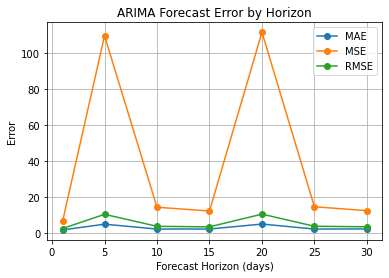

In [5]:
for metric_name in ['MAE', 'MSE','RMSE']:
    values = [res[metric_name] for res in results]
    plt.plot(horizons, values, marker='o', label=metric_name)

plt.title('ARIMA Forecast Error by Horizon')
plt.xlabel('Forecast Horizon (days)')
plt.ylabel('Error')
plt.legend()
plt.grid()
plt.show()

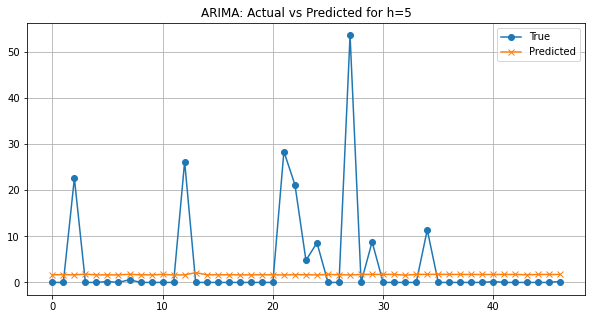

In [11]:
# Filter y_true and y_pred for h=5 or h=20
h = 5  # or 20

y_trues = []
y_preds = []

for i in range(0, len(test) - h, 15):
    train_data = ts[:train_window + i]

    try:
        model = pm.auto_arima(train_data, seasonal=False, suppress_warnings=True, stepwise=True)
        forecast = model.predict(n_periods=h)

        y_pred = forecast[-1]
        y_true = test.iloc[i + h - 1]

        y_trues.append(y_true)
        y_preds.append(y_pred)

    except Exception as e:
        print(str(e))
        continue

# Plot
plt.figure(figsize=(10, 5))
plt.plot(y_trues, label="True", marker='o')
plt.plot(y_preds, label="Predicted", marker='x')
plt.title(f"ARIMA: Actual vs Predicted for h={h}")
plt.xlabel("Forecast Instance")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.grid()
plt.show()


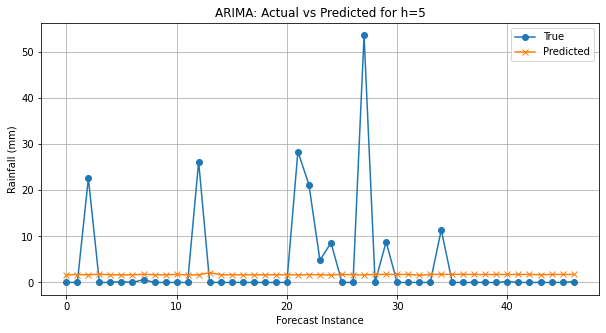

In [12]:
# Plot
plt.figure(figsize=(10, 5))
plt.plot(y_trues, label="True", marker='o')
plt.plot(y_preds, label="Predicted", marker='x')
plt.title(f"ARIMA: Actual vs Predicted for h={h}")
plt.xlabel("Forecast Instance")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.grid()
plt.show()

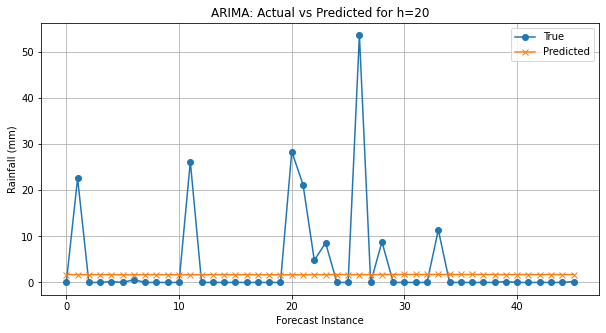

In [13]:
# Filter y_true and y_pred for h=5 or h=20
h = 20

y_trues = []
y_preds = []

for i in range(0, len(test) - h, 15):
    train_data = ts[:train_window + i]

    try:
        model = pm.auto_arima(train_data, seasonal=False, suppress_warnings=True, stepwise=True)
        forecast = model.predict(n_periods=h)

        y_pred = forecast[-1]
        y_true = test.iloc[i + h - 1]

        y_trues.append(y_true)
        y_preds.append(y_pred)

    except Exception as e:
        print(str(e))
        continue

# Plot
plt.figure(figsize=(10, 5))
plt.plot(y_trues, label="True", marker='o')
plt.plot(y_preds, label="Predicted", marker='x')
plt.title(f"ARIMA: Actual vs Predicted for h={h}")
plt.xlabel("Forecast Instance")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.grid()
plt.show()


In [15]:
horizons = [1, 5, 10, 15, 20, 25, 30]
all_trues = []

for h in horizons:
    for i in range(0, len(test) - h, 15):
        y_true = test.iloc[i + h - 1]
        all_trues.append({'horizon': h, 'true': y_true})

# Convert to DataFrame
true_df = pd.DataFrame(all_trues)

# Summary stats per horizon
summary = true_df.groupby("horizon")["true"].describe()
print(summary)


         count      mean        std  min  25%  50%  75%   max
horizon                                                      
1         47.0  0.740426   2.320388  0.0  0.0  0.0  0.1  13.4
5         47.0  3.974468  10.308934  0.0  0.0  0.0  0.2  53.6
10        47.0  1.212766   3.805123  0.0  0.0  0.0  0.2  22.8
15        46.0  1.108696   3.492393  0.0  0.0  0.0  0.0  19.4
20        46.0  4.060870  10.405628  0.0  0.0  0.0  0.2  53.6
25        46.0  1.239130   3.842828  0.0  0.0  0.0  0.2  22.8
30        45.0  1.133333   3.527812  0.0  0.0  0.0  0.0  19.4


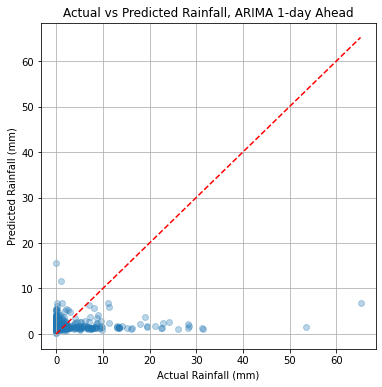

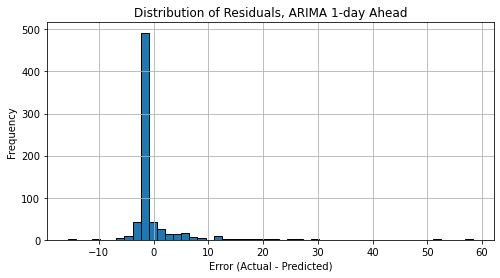

In [6]:
horizons = [1, 5, 10, 15, 20, 25, 30]

# Store results
results = []
errors = []

train_window = int(len(ts) * 0.8)  # 80% train
test = ts[train_window:]

# Use rolling-origin starting from the beginning of test
for h in horizons:
    y_trues = []
    y_preds = []

    for i in range(0, len(test) - h, 1):  # ensure enough future values
        train_data = ts[:train_window + i]

        try:
            # Fit ARIMA on expanding window
            model = pm.auto_arima(train_data, seasonal=False, suppress_warnings=True, stepwise=True)

            # Forecast h steps ahead
            forecast = model.predict(n_periods=h)

            # Save only the h-th forecast
            y_pred = forecast[-1]
            y_true = test.iloc[i + h - 1]

            y_trues.append(y_true)
            y_preds.append(y_pred)
            
        except Exception as e:
            errors.append({'i': i, 'horizon': h, 'error': str(e)})
            continue  # skip any errors

    # Compute metrics
    mae = mean_absolute_error(y_trues, y_preds)
    mse = mean_squared_error(y_trues, y_preds)
    rmse = np.sqrt(mse)

    results.append({'Horizon': h, 'MAE': mae, 'MSE': mse, 'RMSE': rmse})
    
    if h == horizons[0]:
        y_trues_arr = np.array(y_trues)
        y_preds_arr = np.array(y_preds)
        residuals = y_trues_arr - y_preds_arr
        
        plt.figure(figsize=(6, 6))
        plt.scatter(y_trues_arr, y_preds_arr, alpha=0.3)
        plt.plot([0, y_trues_arr.max()], [0, y_trues_arr.max()], '--r')
        plt.xlabel("Actual Rainfall (mm)")
        plt.ylabel("Predicted Rainfall (mm)")
        plt.title("Actual vs Predicted Rainfall, ARIMA 1-day Ahead")
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(8, 4))
        plt.hist(residuals, bins=50, edgecolor='k')
        plt.title("Distribution of Residuals, ARIMA 1-day Ahead")
        plt.xlabel("Error (Actual - Predicted)")
        plt.ylabel("Frequency")
        plt.grid(True)
        plt.show()

In [7]:
results

[{'Horizon': 1,
  'MAE': 2.5935702398816534,
  'MSE': 27.688097165584075,
  'RMSE': 5.261948039042582},
 {'Horizon': 5,
  'MAE': 2.6557237064413406,
  'MSE': 28.209318845507752,
  'RMSE': 5.311244566531252},
 {'Horizon': 10,
  'MAE': 2.656592407659707,
  'MSE': 28.328875482954544,
  'RMSE': 5.3224877156226995},
 {'Horizon': 15,
  'MAE': 2.6251740902783562,
  'MSE': 27.249256014278565,
  'RMSE': 5.220081993060891},
 {'Horizon': 20,
  'MAE': 2.6321868939092568,
  'MSE': 27.42867918640224,
  'RMSE': 5.237239653329055},
 {'Horizon': 25,
  'MAE': 2.637858752998752,
  'MSE': 27.60265698111958,
  'RMSE': 5.253823082396245},
 {'Horizon': 30,
  'MAE': 2.6447864745748344,
  'MSE': 27.787198141481376,
  'RMSE': 5.271356385360543}]

In [8]:
test

Date
2015-07-22    0.2
2015-07-23    6.6
2015-07-24    2.2
2015-07-25    2.4
2015-07-26    0.0
             ... 
2017-06-21    0.2
2017-06-22    0.0
2017-06-23    0.4
2017-06-24    0.0
2017-06-25    0.0
Name: Rainfall, Length: 705, dtype: float64

In [15]:
test_trimmed = test[:-1]

In [16]:
rainfall_data = pd.DataFrame(test_trimmed)

In [17]:
rainfall_data

,Rainfall
Date,
2015-07-22,0.2
2015-07-23,6.6
2015-07-24,2.2
2015-07-25,2.4
2015-07-26,0.0
...,...
2017-06-20,0.0
2017-06-21,0.2
2017-06-22,0.0


In [12]:
y_preds_arr

array([ 1.22569372,  1.24743546,  2.41542498,  2.06489101,  1.9673496 ,
        1.49533374,  1.3148174 ,  1.24569334,  1.21902793,  1.20852253,
        1.20418961,  1.20217407,  6.88590229,  3.58427079,  2.11432453,
        1.5549386 ,  1.34302545,  1.26243909,  1.26752529,  1.23328401,
        1.21994963,  1.21455011,  1.21216347,  1.92905472,  1.48385647,
        1.31446446,  1.2497733 ,  1.22486463,  1.21506609,  1.21100801,
        1.24504748,  1.22179363,  1.46404291,  1.34068645,  1.25758199,
        5.27778662,  3.2220587 ,  2.19127823,  1.58437655,  1.67623524,
        1.38949919,  1.28045092,  1.23880014,  1.22268278,  2.57468201,
        2.62367149,  1.74806921,  1.41651729,  1.29101441,  1.24333658,
        1.22501122,  1.21775838,  1.21468547,  1.21319191,  1.21229568,
        1.21162565,  1.21104148,  1.21049007,  1.20995131,  1.209483  ,
        1.20895213,  1.20842238,  1.20789333,  1.38648182,  1.2749467 ,
        1.2323658 ,  1.21589944,  1.20932939,  1.20651077,  1.20

In [18]:
rainfall_data['Predicted'] = y_preds_arr

In [19]:
rainfall_data['Abs_Error'] = abs(rainfall_data['Rainfall'] - rainfall_data['Predicted'])

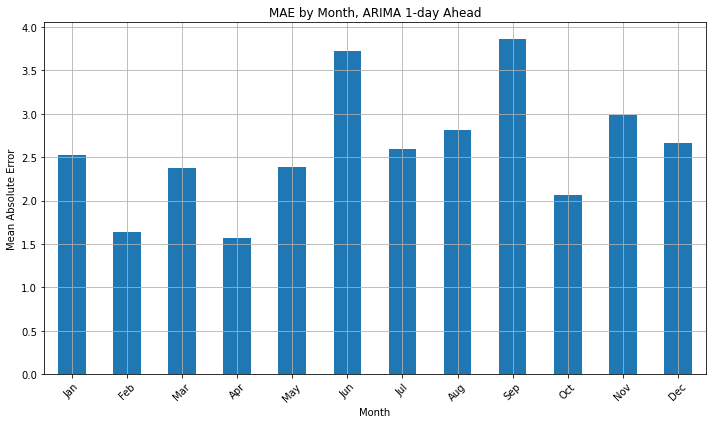

In [21]:
monthly_error = rainfall_data.groupby(rainfall_data.index.month)['Abs_Error'].mean()

# Plotting
ax = monthly_error.plot(kind='bar', figsize=(10, 6), title='MAE by Month, ARIMA 1-day Ahead')
ax.set_xlabel("Month")
ax.set_ylabel("Mean Absolute Error")

# Replace x-tick labels with month names
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)

plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
monthly_error

Date
1     2.528545
2     1.640872
3     2.376400
4     1.571197
5     2.387960
6     3.723416
7     2.598904
8     2.814057
9     3.860888
10    2.064687
11    2.988925
12    2.658408
Name: Abs_Error, dtype: float64

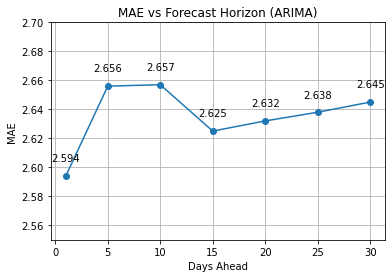

In [5]:
# Trend Over forecast horizon

# list of MAE per horizon
horizons = [1, 5, 10, 15, 20, 25, 30]
mae_per_horizon = [2.594, 2.656, 2.657, 2.625, 2.632, 2.638, 2.645]

plt.plot(horizons, mae_per_horizon, marker='o')
plt.title("MAE vs Forecast Horizon (ARIMA)")
plt.xlabel("Days Ahead")
plt.ylabel("MAE")
plt.ylim(2.55, 2.7)
plt.grid(True)
for x, y in zip(horizons, mae_per_horizon):
    plt.text(x, y + 0.01, f"{y:.3f}", ha='center')
plt.show()


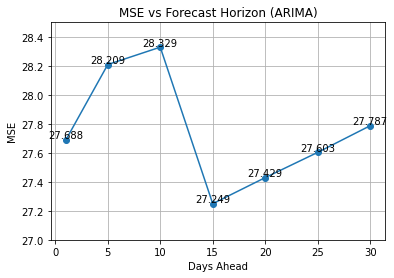

In [6]:
# Trend Over forecast horizon

# list of MSE per horizon
horizons = [1, 5, 10, 15, 20, 25, 30]
mse_per_horizon = [27.688, 28.209, 28.329, 27.249, 27.429, 27.603, 27.787]

plt.plot(horizons, mse_per_horizon, marker='o')
plt.title("MSE vs Forecast Horizon (ARIMA)")
plt.xlabel("Days Ahead")
plt.ylabel("MSE")
plt.ylim(27, 28.5)
plt.grid(True)
for x, y in zip(horizons, mse_per_horizon):
    plt.text(x, y + 0.01, f"{y:.3f}", ha='center')
plt.show()


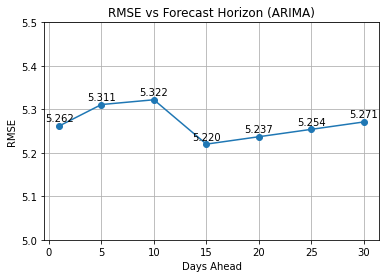

In [7]:
# Trend Over forecast horizon

# list of RMSE per horizon
horizons = [1, 5, 10, 15, 20, 25, 30]
rmse_per_horizon = [5.262, 5.311, 5.322, 5.220, 5.237, 5.254, 5.271]

plt.plot(horizons, rmse_per_horizon, marker='o')
plt.title("RMSE vs Forecast Horizon (ARIMA)")
plt.xlabel("Days Ahead")
plt.ylabel("RMSE")
plt.ylim(5, 5.5)
plt.grid(True)
for x, y in zip(horizons, rmse_per_horizon):
    plt.text(x, y + 0.01, f"{y:.3f}", ha='center')
plt.show()
